THE EDA THINKING FRAMEWORK

1. What is the data?
2. How big is it?
3. What types of variables exist?
4. How does each variable behave alone?
5. How do variables interact?
6. What business meaning does this have?
 

In [49]:
import pandas as pd
import numpy as np


In [50]:
customers = pd.read_csv("olist_customers_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")


In [51]:
customers.head()


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [52]:
orders.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [53]:
customers.shape


(99441, 5)

In [54]:
orders.columns


Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [55]:
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

orders['order_delivered_customer_date'] = pd.to_datetime(
    orders['order_delivered_customer_date']
)


In [56]:
df = orders.merge(customers, on="customer_id", how="left")
df = df.merge(order_items, on="order_id", how="left")
df = df.merge(products, on="product_id", how="left")
df = df.merge(payments, on="order_id", how="left")
df = df.merge(reviews, on="order_id", how="left")


In [57]:
df.isnull().sum()


order_id                              0
customer_id                           0
order_status                          0
order_purchase_timestamp              0
order_approved_at                   177
order_delivered_carrier_date       2086
order_delivered_customer_date      3421
order_estimated_delivery_date         0
customer_unique_id                    0
customer_zip_code_prefix              0
customer_city                         0
customer_state                        0
order_item_id                       833
product_id                          833
seller_id                           833
shipping_limit_date                 833
price                               833
freight_value                       833
product_category_name              2542
product_name_lenght                2542
product_description_lenght         2542
product_photos_qty                 2542
product_weight_g                    853
product_length_cm                   853
product_height_cm                   853


In [58]:
df['review_score'] = df['review_score'].fillna(
    df['review_score'].median()
)


In [59]:
df['is_delivered'] = df['order_delivered_customer_date'].notna().astype(int)
df['is_approved'] = df['order_approved_at'].notna().astype(int)
df['delivery_days'] = (
    df['order_delivered_customer_date']
    - df['order_purchase_timestamp']
).dt.days


In [60]:
df = df.dropna(subset=['product_id', 'price'])


In [61]:
df['product_category_name'].fillna('unknown', inplace=False)

for col in ['product_weight_g', 'product_length_cm',
            'product_height_cm', 'product_width_cm']:
    df[col] = df[col].fillna(df[col].median())


In [62]:
df = df.dropna(subset=['payment_value'])


In [63]:
df['review_score'] = df['review_score'].fillna(0)


In [64]:
df['has_review'] = (df['review_score'] > 0).astype(int)


In [65]:
df['review_comment_title'] = df['review_comment_title'].fillna('no_comment')
df['review_comment_message'] = df['review_comment_message'].fillna('no_comment')


In [66]:
df['reviewed'] = df['review_creation_date'].notna().astype(int)


In [67]:
df.isnull().sum()


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1254
order_delivered_customer_date    2588
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
product_category_name            1709
product_name_lenght              1709
product_description_lenght       1709
product_photos_qty               1709
product_weight_g                    0
product_length_cm                   0
product_height_cm                   0
product_width_cm                    0
payment_sequ

In [68]:
df = df.dropna(subset=['product_category_name'])


In [69]:
df.isnull().sum()


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  14
order_delivered_carrier_date     1215
order_delivered_customer_date    2517
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
product_category_name               0
product_name_lenght                 0
product_description_lenght          0
product_photos_qty                  0
product_weight_g                    0
product_length_cm                   0
product_height_cm                   0
product_width_cm                    0
payment_sequ

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")


Understand overall sales, orders, and products.

In [71]:
total_revenue = df['payment_value'].sum()
total_revenue


np.float64(20163115.22)

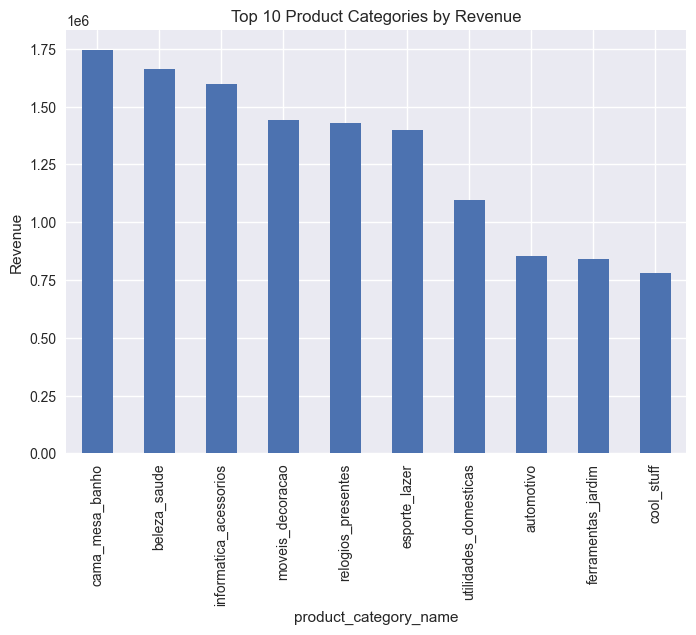

In [72]:
category_revenue = (
    df.groupby('product_category_name')['payment_value']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

category_revenue.plot(kind='bar')
plt.title("Top 10 Product Categories by Revenue")
plt.ylabel("Revenue")
plt.show()


A few categories dominate revenue so inventory & marketing focus needed

Analyze how customers behave and spend.

In [73]:
orders_per_customer = df.groupby('customer_unique_id')['order_id'].nunique()
orders_per_customer.describe()


count    94107.000000
mean         1.033674
std          0.208940
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         15.000000
Name: order_id, dtype: float64

Is the business dependent on new customers or loyal customers?

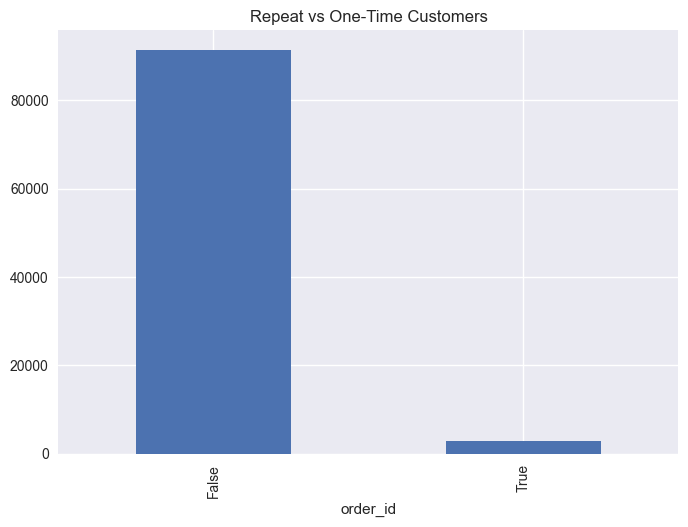

In [74]:
repeat_customers = (orders_per_customer > 1).value_counts()
repeat_customers.plot(kind='bar')
plt.title("Repeat vs One-Time Customers")
plt.show()


In [75]:
aov = df.groupby('order_id')['payment_value'].sum().mean()
aov


np.float64(207.27738825609603)

Most customers are one-time buyers so retention opportunity exists.

Identify demand trends & seasonality.

In [76]:
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')


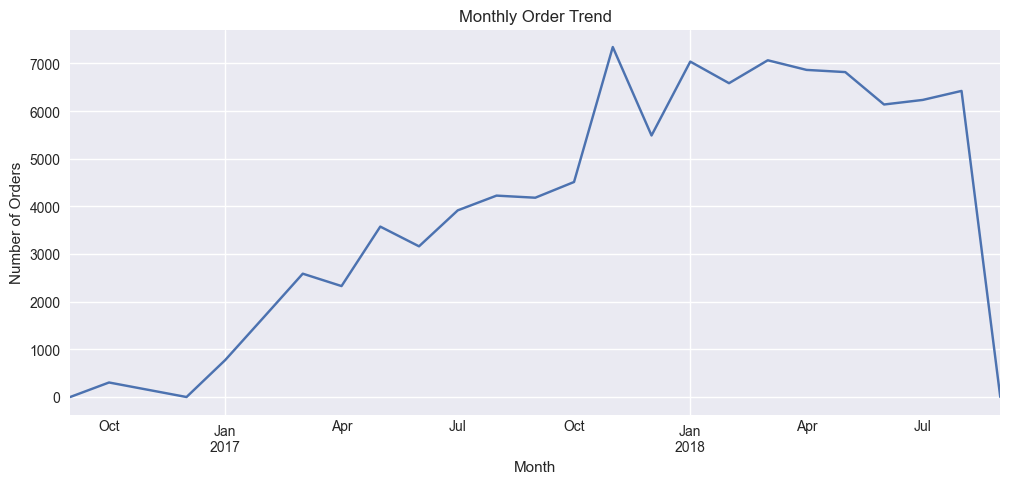

In [77]:
monthly_orders = df.groupby('order_month')['order_id'].nunique()

monthly_orders.plot(figsize=(12,5))
plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.show()


Demand shows clear growth & seasonal peaks
Useful for campaign planning.

Understand regional demand & logistics issues.

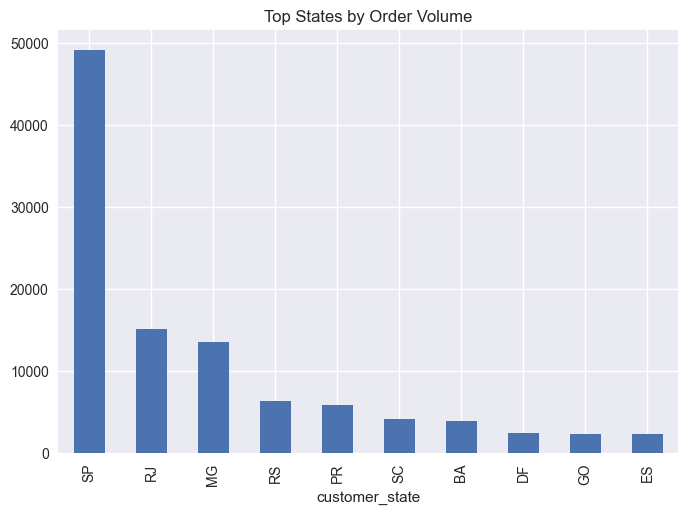

In [78]:
state_orders = df['customer_state'].value_counts()

state_orders.head(10).plot(kind='bar')
plt.title("Top States by Order Volume")
plt.show()


DELIVERY TIME ANALYSIS

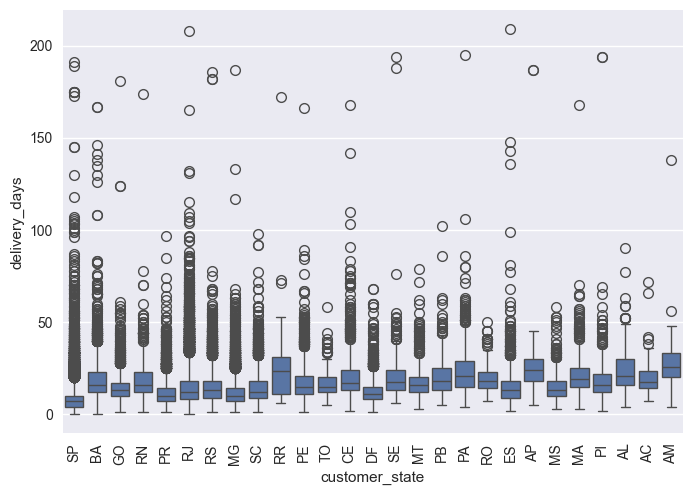

In [79]:
df['delivery_days'] = (
    df['order_delivered_customer_date'] -
    df['order_purchase_timestamp']
).dt.days

sns.boxplot(x='customer_state', y='delivery_days', data=df)
plt.xticks(rotation=90)
plt.show()


Some states have high demand but slower delivery so logistics bottleneck.

How to compare states

Lower median = faster typical delivery
Higher median = slower delivery

States like SP, RJ, MG have lower medians
Remote states (e.g. AM, AC) have higher medians
So Geography affects delivery speed

Now delivery consitency 

box height show delivery consitency 
Short box = consistent delivery
Tall box = unpredictable delivery

insight
Major states have more consistent logistics
Smaller/remote states show high variability

Outliers
Some state have many outliers and Extremely high delivery dayes
this can happen due to many problems like
supply chain issue 
remote location 
some other issues etc,

Summary

  1. Logistics efficiency is location-dependent
  2. Customer experience is unequal
  3. Outliers are operational risks

DELIVERY VS REVIEWS

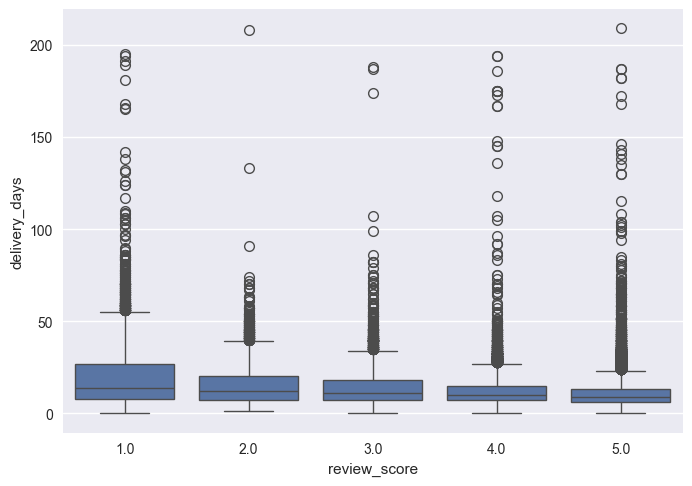

In [80]:
sns.boxplot(x='review_score', y='delivery_days', data=df)
plt.show()


Translate analysis into business decisions.

## Key Findings

1. Revenue is concentrated in few categories
2. Majority customers are one-time buyers
3. Clear monthly demand seasonality exists
4. Delivery delays negatively impact reviews
5. Regional logistics performance varies


## Recommendations

- Focus marketing on high-revenue categories
- Introduce loyalty programs
- Improve logistics in high-delay states
- Schedule campaigns before demand peaks


Revenue Quality & Revenue Concentration Analysis

Is revenue evenly distributed, or dependent on a small group of customers/products?

In [81]:
customer_revenue = (
    df.groupby("customer_unique_id")["payment_value"]
      .sum()
      .sort_values(ascending=False)
)


In [82]:
total_revenue = customer_revenue.sum()

top_20_percent_count = int(0.2 * len(customer_revenue))
top_20_percent_revenue = customer_revenue.head(top_20_percent_count).sum()

top_20_percent_revenue / total_revenue * 100


np.float64(61.96525122073869)

The business is highly dependent on a small group of customers, which increases risk if these customers leave.

Customer Lifetime & Value Analysis

In [83]:
customer_lifetime = (
    df.groupby("customer_unique_id")["order_purchase_timestamp"]
      .agg(["min", "max"])
)

customer_lifetime["lifetime_days"] = (
    customer_lifetime["max"] - customer_lifetime["min"]
).dt.days

customer_lifetime.head()



,min,max,lifetime_days
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,2018-05-10 10:56:27,0
0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,2018-05-07 11:11:27,0
0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,2017-03-10 21:05:03,0
0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,2017-10-12 20:29:41,0
0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,2017-11-14 19:45:42,0


In [84]:
customer_summary = customer_lifetime.merge(
    customer_revenue,
    left_index=True,
    right_index=True
)

customer_summary.rename(columns={"payment_value": "total_revenue"}, inplace=True)

customer_summary.head()


,min,max,lifetime_days,total_revenue
customer_unique_id,,,,
0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,2018-05-10 10:56:27,0,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,2018-05-07 11:11:27,0,27.19
0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,2017-03-10 21:05:03,0,86.22
0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,2017-10-12 20:29:41,0,43.62
0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,2017-11-14 19:45:42,0,196.89


In [85]:
customer_summary["value_segment"] = pd.qcut(
    customer_summary["total_revenue"],
    q=3,
    labels=["Low Value", "Medium Value", "High Value"]
)

customer_summary["value_segment"].value_counts()


value_segment
Low Value       31374
High Value      31368
Medium Value    31365
Name: count, dtype: int64

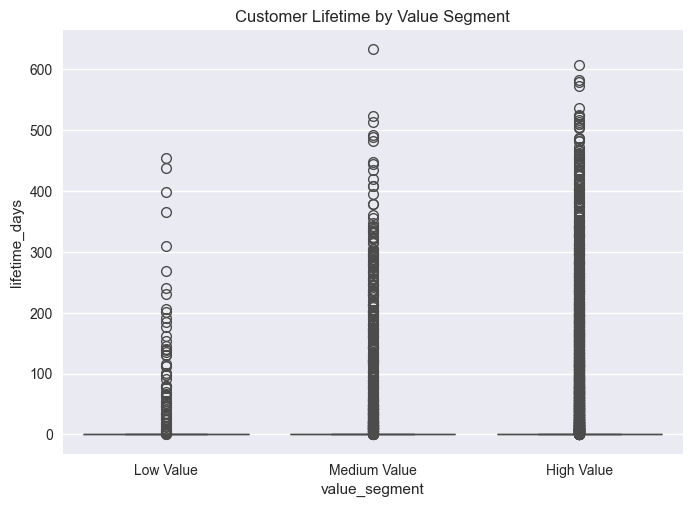

In [86]:
sns.boxplot(
    x="value_segment",
    y="lifetime_days",
    data=customer_summary.reset_index()
)
plt.title("Customer Lifetime by Value Segment")
plt.show()


A heavy concentration of customers with zero lifetime, indicating a high proportion of one-time buyers.
As customer value increases, the lifetime distribution spreads upward, showing that high-value customers tend to stay active longer and contribute more revenue over time

Order Economics & Basket 
    This shows how customers buy, not just what.

In [87]:
items_per_order = df.groupby("order_id")["order_item_id"].count()
items_per_order.describe()


count    97276.000000
mean         1.198631
std          0.751239
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         63.000000
Name: order_item_id, dtype: float64

Most orders contain only 1 item → cross-selling opportunity

Order Value Distribution

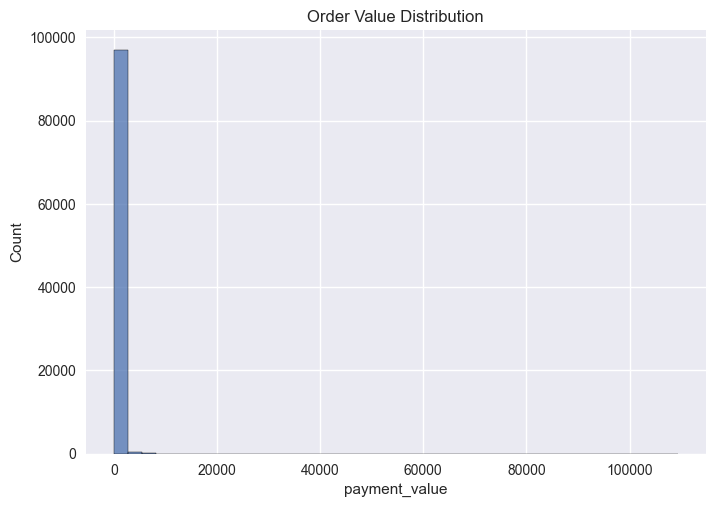

In [88]:
order_value = df.groupby("order_id")["payment_value"].sum()

sns.histplot(order_value, bins=40)
plt.title("Order Value Distribution")
plt.show()


In [93]:
order_value.describe()


count     97276.000000
mean        207.277388
std         625.782634
min           9.590000
25%          63.000000
50%         110.020000
75%         197.170000
max      109312.640000
Name: payment_value, dtype: float64

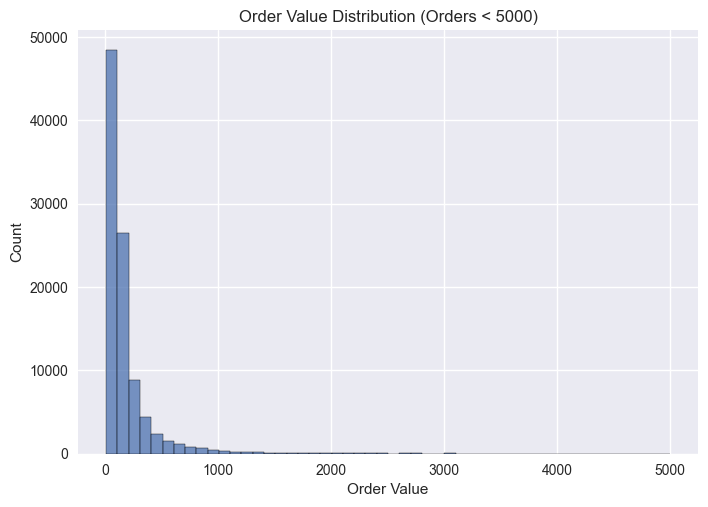

In [89]:
sns.histplot(order_value[order_value < 5000], bins=50)
plt.title("Order Value Distribution (Orders < 5000)")
plt.xlabel("Order Value")
plt.show()


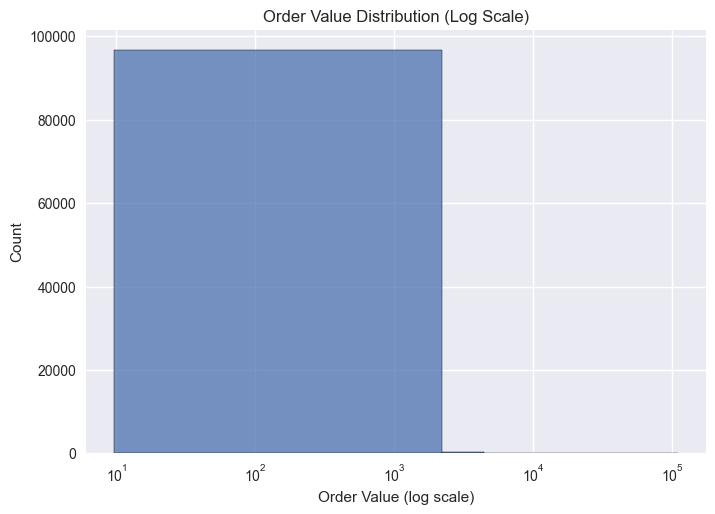

In [90]:
sns.histplot(order_value, bins=50)
plt.xscale("log")
plt.title("Order Value Distribution (Log Scale)")
plt.xlabel("Order Value (log scale)")
plt.show()


The apparent uniform bar height occurs because the histogram bins are created linearly, while the x-axis is scaled logarithmically. To properly visualize skewed data on a log scale, the bins themselves must also be logarithmically spaced.

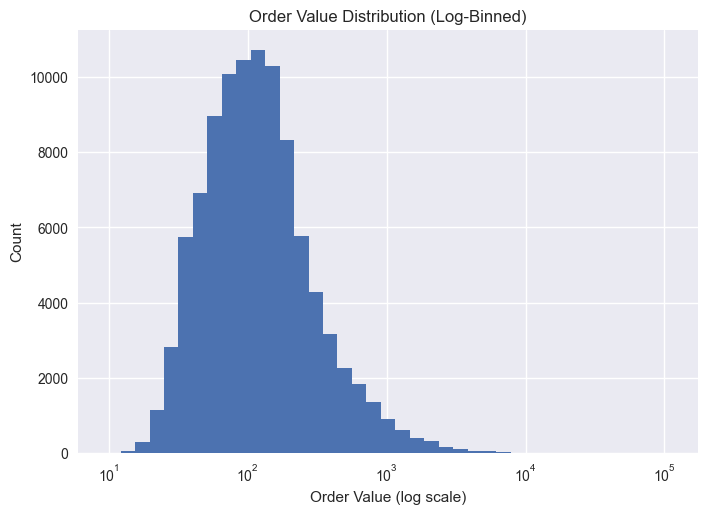

In [92]:

bins = np.logspace(
    np.log10(order_value.min()),
    np.log10(order_value.max()),
    40
)

plt.hist(order_value, bins=bins)
plt.xscale("log")
plt.xlabel("Order Value (log scale)")
plt.ylabel("Count")
plt.title("Order Value Distribution (Log-Binned)")
plt.show()


Because order values span several orders of magnitude, we used logarithmically spaced bins to ensure that each bin represents a proportional increase in value. This prevents low-value orders from dominating the histogram and allows meaningful comparison across scales.

Insight
A few expensive orders contribute significantly to revenue

Operational Efficiency & Customer Experience

In [95]:
delivery_review = (
    df.groupby("review_score")["delivery_days"]
      .agg(["mean", "median", "count"])
)

delivery_review


,mean,median,count
review_score,,,
1.0,19.134887,14.0,12870
2.0,15.298022,12.0,3842
3.0,13.564643,11.0,9537
4.0,11.780028,10.0,21821
5.0,10.295557,9.0,66011


Lower review scores are strongly associated with longer delivery times.

In [96]:
df["late_delivery"] = df["delivery_days"] > 10
df["late_delivery"].value_counts(normalize=True) * 100


late_delivery
False    55.209352
True     44.790648
Name: proportion, dtype: float64

Geographic Business Risk Analysis

In [97]:
state_summary = df.groupby("customer_state").agg(
    total_revenue=("payment_value", "sum"),
    avg_delivery_days=("delivery_days", "mean"),
    total_orders=("order_id", "nunique")
)

state_summary.sort_values("total_revenue", ascending=False).head(10)


,total_revenue,avg_delivery_days,total_orders
customer_state,,,
SP,7554985.51,8.270931,40810
RJ,2748296.13,14.785172,12571
MG,2311970.57,11.505370,11378
RS,1136641.71,14.695927,5353
PR,1058906.29,11.512208,4928
BA,788348.82,18.749871,3315
SC,779608.48,14.492101,3554
GO,507733.14,14.792735,1960
DF,432733.16,12.498965,2094


Some high-revenue states also have high delivery delays → operational bottleneck.

SP (São Paulo)
    Highest revenue
    Highest number of orders
    Fastest delivery among top state
Which means
    SP is the core market.
    High demand + high revenue + efficient logistic

RJ (Rio de Janeiro)
    Second-highest revenue
    Delivery almost twice as slow as SP
Which means
    Strong demand, but operational inefficiency.

This table summarizes state-level performance across revenue, demand, and delivery efficiency. São Paulo dominates in both revenue and order volume while also maintaining the fastest delivery times, making it the most critical market. In contrast, states like Bahia exhibit lower revenue and significantly higher delivery times, indicating operational challenges that may be limiting growth.

Final Conclusion

Through advanced exploratory data analysis, we observed that the e-commerce platform’s revenue is highly concentrated among a small segment of customers and regions. Most customers are one-time buyers with very short lifetimes, while long-term customers contribute disproportionately higher revenue. Order values are heavily right-skewed, indicating dependence on a large volume of low-value orders and a small number of high-value transactions. Operational efficiency, particularly delivery time, varies significantly across regions and shows a strong association with customer satisfaction and revenue performance. Overall, the analysis highlights customer retention and logistics optimization as the key levers for sustainable growth

Based on these insights, improving customer retention and regional logistics efficiency would have the highest impact on long-term business performance